# Fine guidance PIC (fgPIC) 2.2.0.1

This notebook explores the fgPIC 2.2.0.1 catalogue.

**Prerequsites** 

To run this notebook you need to download the PIC 2.1.0.1 from the [PAX](https://pax.esac.esa.int/plato/#/pages/catalog-explorer). Unzip the following two files:

- `LOPS2PICtarget2.2.0.1-t-fg-c-scv.fits`
- `LOPS2PICcontaminant2.2.0.1-t-fg-c-scv.fits`

and place them in the location: `$PLATO_PROJECT_HOME/inputfiles/data_picsim`.

**Documentation** 

The following technical notes helps you understand the PIC:

- `LOPS2PIC2.2.0.1 Release Notes (for PIC users)`
- `LOPS2PIC2.2.0.1 Data Definition Document`

**Last checked** 

This notebook was last functional with the PlatoSim version:

- `PlatoSim 3.7.0-191-g42fc64d4`

In [1]:
%load_ext autoreload
%autoreload 2
%matplotlib notebook

In [2]:
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from astropy.time import Time
from astropy import units as u
from astropy import constants as c
from astropy.coordinates import SkyCoord
from tqdm import tqdm
from pathlib import Path

# PlatoSim libraries
import platosim.slurm     as sm
import platosim.utilities as ut
import platosim.plot      as pt
import platosim.noise     as ns
import platosim.starquery as sq
import platosim.pic       as pic
from platosim.hpc          import HPC
from platosim.slurm        import getParamFile
from platosim.lightcurve   import LightCurve
from platosim.matplotlibrc import setup_notebook
setup_notebook()

from IPython.display import display, HTML
display(HTML("<style>.container {width:90% !important; }</style>"))

In [3]:
# Paths to where data is stored
path = ut.getHomeDir('inputfiles/data_picsim')
wdir = ut.getWorkDir('plato_fgPIC')
idir = wdir / 'input'
ddir = wdir / 'data'
sdir = wdir / 'sims'
odir = wdir / 'output'
fdir = wdir / 'figures'

## Load fgPIC

In [14]:
# Load tPIC catalogue
df = pic.load_pic()

In [15]:
# Trim to fgPIC catalogue
dt = df.loc[df.source & 8 == 8]
dt

,PIC,gaiaDR3,l,b,ra,dec,pmra,pmdec,Pmag,PBmag,...,R,Teff,logg,ncams,case,source,tPIC,fgPIC,cPIC,scvPIC
13032,3017467001146,b'Gaia DR3 5284015148063097600',276.560754,-28.457784,93.420676,-66.679597,-2.466818,56.272407,6.997335,7.152997,...,3.062467,6482.063662,3.703180,12,1,29,35,3,607,0
13967,3012359000058,b'Gaia DR3 5284415718191501568',276.219880,-27.538512,95.665334,-66.312969,18.381680,-66.593707,8.310672,8.513293,...,2.272844,5972.044174,3.877539,12,1,28,1,2,607,0
14966,3009269000159,b'Gaia DR3 5282036164572097024',276.478887,-23.700973,105.115179,-65.907678,-24.645888,130.103477,8.099881,8.311864,...,1.277018,5879.213655,4.279311,12,1,29,35,1,607,0
16147,3003981000194,b'Gaia DR3 5283775248372238336',275.567922,-25.521144,100.374885,-65.469140,-12.014263,-56.584098,7.591249,7.767465,...,1.344363,6236.850613,4.269371,12,1,29,35,3,607,0
18539,2993144000091,b'Gaia DR3 5285408645909168128',274.961667,-23.778268,104.153269,-64.576263,69.226663,-10.028462,8.537162,8.727257,...,1.016656,6090.555360,4.456769,12,1,29,33,2,1010,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
219990,2722206000090,b'Gaia DR3 5530581081569420800',260.612041,-10.740979,116.896654,-47.012885,-4.729252,8.909600,7.009299,6.978394,...,3.707120,17361.600000,4.051927,<NA>,5,8,0,3,0,0
219991,2723926000103,b'Gaia DR3 5554919286840878592',254.716218,-25.476096,93.701287,-47.011923,2.333413,-12.949466,7.564082,8.015290,...,13.439800,4770.830000,2.701989,24,4,56,0,3,576,8192
219992,2724041000548,b'Gaia DR3 5530534489762698496',260.368249,-11.176834,116.167432,-47.008411,-13.445399,8.263929,6.772204,6.752637,...,3.267930,13224.500000,3.995558,<NA>,5,8,0,3,0,0
219993,2722050000028,b'Gaia DR3 4795931357989249664',253.656812,-30.325040,86.456360,-47.006700,-32.065483,-14.277241,7.009899,7.120751,...,2.144830,6972.680000,3.989556,24,3,40,0,3,0,2048


<IPython.core.display.Javascript object>


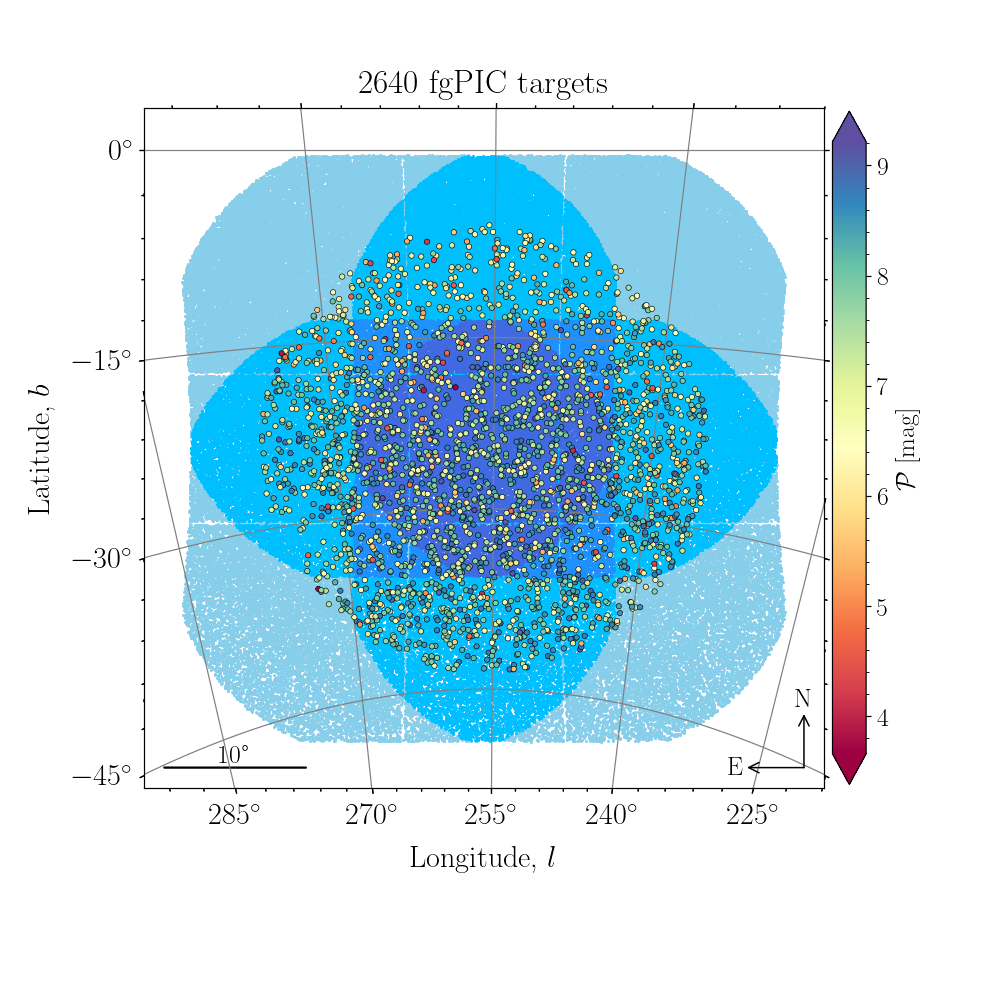

In [6]:
# Plot target in Galactic projection
fig, ax = pt.plotPlatoFOV(
    'LOPS2', system='galactic', fovSize=30, ncamStars=True,
    raStars=dt.ra, decStars=dt.dec, c=dt.Pmag,
    clabel=r'$\mathcal{P}$ [mag]', s=50, lw=0.4,
    title=f'{dt.shape[0]} fgPIC targets', figsize=(9,9),
)

## Compute the SPR

#### Prepare simulations

In [16]:
# Create target catalogue
dt.reset_index(drop=True, inplace=True)
dt.to_feather(idir / f'starcat_fgPIC_targets.ftr')

In [17]:
# Load PIC LOSP2 catalogue
dc = pd.read_feather(path / 'PlatoGO_PIC220_LOPS2.ftr')
dc.head()

,PIC,gaiaDR3,ra,dec,Gmag,Pmag,PBmag,PRmag
0,3110756000112,Gaia DR3 5212190448627272832,95.193683,-77.886883,15.213778,14.926610,15.235669,14.596222
1,3110756000113,Gaia DR3 5212190616130246656,95.141286,-77.886858,18.240141,17.982211,18.237360,17.696458
2,3110755000134,Gaia DR3 5212191960455806208,94.689049,-77.885060,18.910688,18.488089,19.384377,17.854926
3,3110757000131,Gaia DR3 5212236623819501824,95.869891,-77.885061,17.671410,17.447247,17.651479,17.208032
4,3110757000132,Gaia DR3 5212236417661073152,95.765300,-77.884838,18.137350,17.830000,18.183424,17.466040


In [25]:
# Create contaminant catalogue
dc = ut.getContaminants(dt, dc, column='PIC')
dc.to_feather(idir / f'starcat_fgPIC_contaminants.ftr')

100%|██████████████████████████████████████████████████| 2640/2640 [06:17<00:00,  6.98it/s]                                                                


In [31]:
# Create an parameterisation file
N = dt.shape[0]
getParamFile(range(1,N+1), range(5,6), range(1,2), range(1,2), ofile=idir/'cluster_fcamb.data')
getParamFile(range(1,N+1), range(5,6), range(2,3), range(1,2), ofile=idir/'cluster_fcamr.data');

#### Run simulations

In [26]:
path_b = sdir / 'fcamb'
path_r = sdir / 'fcamr'

In [28]:
# Run simulation for F-CAM blue
hpc = HPC('plato_fgPIC', cpus=6)
hpc.run(
    script='platonium', 
    param_file='cluster_fcamb.data', 
    kwargs='--performance expected --nexp 1 -w -v 0',
    odir=path_b,
)

100%|██████████████████████████████████████████████████| 2640/2640 [33:58<00:00,  1.30it/s]                                                                


In [29]:
# Run simulation for F-CAM blue
hpc = HPC('plato_fgPIC', cpus=6)
hpc.run(
    script='platonium', 
    param_file='cluster_fcamr.data',  
    kwargs='--performance expected --nexp 1 -w -v 0',
    odir=path_r,
)

100%|██████████████████████████████████████████████████| 2640/2640 [34:53<00:00,  1.26it/s]                                                                


#### Add simulation information to main catalogue

In [116]:
path_b = sdir / 'fcamb'
path_r = sdir / 'fcamr'
# Fetch extra parameters from simulation tables
ncon_b =  np.zeros(N)
ncon_r = np.zeros(N) 
SPR_b =  np.zeros(N)
SPR_r = np.zeros(N)
NSR_b =  np.zeros(N)
NSR_r = np.zeros(N)
for i in range(1, N+1):
    star = f'{i}'.zfill(9)
    lcs_b = LightCurve(path_b/star, mode='multi')
    lcs_r = LightCurve(path_r/star, mode='multi')
    # Create table with simulation statistics
    if lcs_b.files(group=5) is not None:
        dt_b = lcs_b.stat_sim_table(ofile=path_b/f'table_{star}.ftr', group=5, verbose=False)
        dt_r = lcs_r.stat_sim_table(ofile=path_r/f'table_{star}.ftr', group=5, verbose=False)
#         print(dt_b.SPR.iloc[0], dt_r.SPR.iloc[0]); sys.exit()
        ncon_b[i-1] = dt_b.ncon.iloc[0]
        ncon_r[i-1] = dt_r.ncon.iloc[0]
        SPR_b[i-1]  = dt_b.SPR.iloc[0]
        SPR_r[i-1]  = dt_r.SPR.iloc[0]
        NSR_b[i-1]  = dt_b.NSR.mean()
        NSR_r[i-1]  = dt_r.NSR.mean()
    else:
        ncon_b[i-1] = None
        ncon_r[i-1] = None
        SPR_b[i-1]  = None
        SPR_r[i-1]  = None
        NSR_b[i-1]  = None
        NSR_r[i-1]  = None
# Add sim columns
dt0 = dt.copy()
dt0['ncon'] = ncon_b
dt0['SPR_b'] = SPR_b
dt0['SPR_r'] = SPR_r
dt0['NSR_b'] = NSR_b
dt0['NSR_r'] = NSR_r

[Warning]: No files found with suffix hdf5! Check path: /lhome/nicholas/software/workdir/plato_fgPIC/sims/fcamb/000000001
[Warning]: No files found with suffix hdf5! Check path: /lhome/nicholas/software/workdir/plato_fgPIC/sims/fcamb/000000002
[Warning]: No files found with suffix hdf5! Check path: /lhome/nicholas/software/workdir/plato_fgPIC/sims/fcamb/000000003
[Warning]: No files found with suffix hdf5! Check path: /lhome/nicholas/software/workdir/plato_fgPIC/sims/fcamb/000000009
[Warning]: No files found with suffix hdf5! Check path: /lhome/nicholas/software/workdir/plato_fgPIC/sims/fcamb/000000010
[Warning]: No files found with suffix hdf5! Check path: /lhome/nicholas/software/workdir/plato_fgPIC/sims/fcamb/000000011
[Warning]: No files found with suffix hdf5! Check path: /lhome/nicholas/software/workdir/plato_fgPIC/sims/fcamb/000000015
[Warning]: No files found with suffix hdf5! Check path: /lhome/nicholas/software/workdir/plato_fgPIC/sims/fcamb/000000019
[Warning]: No files foun

[Warning]: No files found with suffix hdf5! Check path: /lhome/nicholas/software/workdir/plato_fgPIC/sims/fcamb/000000187
[Warning]: No files found with suffix hdf5! Check path: /lhome/nicholas/software/workdir/plato_fgPIC/sims/fcamb/000000203
[Warning]: No files found with suffix hdf5! Check path: /lhome/nicholas/software/workdir/plato_fgPIC/sims/fcamb/000000209
[Warning]: No files found with suffix hdf5! Check path: /lhome/nicholas/software/workdir/plato_fgPIC/sims/fcamb/000000217
[Warning]: No files found with suffix hdf5! Check path: /lhome/nicholas/software/workdir/plato_fgPIC/sims/fcamb/000000275
[Warning]: No files found with suffix hdf5! Check path: /lhome/nicholas/software/workdir/plato_fgPIC/sims/fcamb/000000276
[Warning]: No files found with suffix hdf5! Check path: /lhome/nicholas/software/workdir/plato_fgPIC/sims/fcamb/000000283
[Warning]: No files found with suffix hdf5! Check path: /lhome/nicholas/software/workdir/plato_fgPIC/sims/fcamb/000000289
[Warning]: No files foun

[Warning]: No files found with suffix hdf5! Check path: /lhome/nicholas/software/workdir/plato_fgPIC/sims/fcamb/000000499
[Warning]: No files found with suffix hdf5! Check path: /lhome/nicholas/software/workdir/plato_fgPIC/sims/fcamb/000000501
[Warning]: No files found with suffix hdf5! Check path: /lhome/nicholas/software/workdir/plato_fgPIC/sims/fcamb/000000502
[Warning]: No files found with suffix hdf5! Check path: /lhome/nicholas/software/workdir/plato_fgPIC/sims/fcamb/000000503
[Warning]: No files found with suffix hdf5! Check path: /lhome/nicholas/software/workdir/plato_fgPIC/sims/fcamb/000000504
[Warning]: No files found with suffix hdf5! Check path: /lhome/nicholas/software/workdir/plato_fgPIC/sims/fcamb/000000505
[Warning]: No files found with suffix hdf5! Check path: /lhome/nicholas/software/workdir/plato_fgPIC/sims/fcamb/000000506
[Warning]: No files found with suffix hdf5! Check path: /lhome/nicholas/software/workdir/plato_fgPIC/sims/fcamb/000000507
[Warning]: No files foun

[Warning]: No files found with suffix hdf5! Check path: /lhome/nicholas/software/workdir/plato_fgPIC/sims/fcamb/000000721
[Warning]: No files found with suffix hdf5! Check path: /lhome/nicholas/software/workdir/plato_fgPIC/sims/fcamb/000000723
[Warning]: No files found with suffix hdf5! Check path: /lhome/nicholas/software/workdir/plato_fgPIC/sims/fcamb/000000724
[Warning]: No files found with suffix hdf5! Check path: /lhome/nicholas/software/workdir/plato_fgPIC/sims/fcamb/000000727
[Warning]: No files found with suffix hdf5! Check path: /lhome/nicholas/software/workdir/plato_fgPIC/sims/fcamb/000000728
[Warning]: No files found with suffix hdf5! Check path: /lhome/nicholas/software/workdir/plato_fgPIC/sims/fcamb/000000730
[Warning]: No files found with suffix hdf5! Check path: /lhome/nicholas/software/workdir/plato_fgPIC/sims/fcamb/000000732
[Warning]: No files found with suffix hdf5! Check path: /lhome/nicholas/software/workdir/plato_fgPIC/sims/fcamb/000000734
[Warning]: No files foun

[Warning]: No files found with suffix hdf5! Check path: /lhome/nicholas/software/workdir/plato_fgPIC/sims/fcamb/000000932
[Warning]: No files found with suffix hdf5! Check path: /lhome/nicholas/software/workdir/plato_fgPIC/sims/fcamb/000000933
[Warning]: No files found with suffix hdf5! Check path: /lhome/nicholas/software/workdir/plato_fgPIC/sims/fcamb/000000936
[Warning]: No files found with suffix hdf5! Check path: /lhome/nicholas/software/workdir/plato_fgPIC/sims/fcamb/000000937
[Warning]: No files found with suffix hdf5! Check path: /lhome/nicholas/software/workdir/plato_fgPIC/sims/fcamb/000000938
[Warning]: No files found with suffix hdf5! Check path: /lhome/nicholas/software/workdir/plato_fgPIC/sims/fcamb/000000939
[Warning]: No files found with suffix hdf5! Check path: /lhome/nicholas/software/workdir/plato_fgPIC/sims/fcamb/000000940
[Warning]: No files found with suffix hdf5! Check path: /lhome/nicholas/software/workdir/plato_fgPIC/sims/fcamb/000000942
[Warning]: No files foun

...

[Warning]: No files found with suffix hdf5! Check path: /lhome/nicholas/software/workdir/plato_fgPIC/sims/fcamb/000001365
[Warning]: No files found with suffix hdf5! Check path: /lhome/nicholas/software/workdir/plato_fgPIC/sims/fcamb/000001366
[Warning]: No files found with suffix hdf5! Check path: /lhome/nicholas/software/workdir/plato_fgPIC/sims/fcamb/000001367
[Warning]: No files found with suffix hdf5! Check path: /lhome/nicholas/software/workdir/plato_fgPIC/sims/fcamb/000001368
[Warning]: No files found with suffix hdf5! Check path: /lhome/nicholas/software/workdir/plato_fgPIC/sims/fcamb/000001369
[Warning]: No files found with suffix hdf5! Check path: /lhome/nicholas/software/workdir/plato_fgPIC/sims/fcamb/000001371
[Warning]: No files found with suffix hdf5! Check path: /lhome/nicholas/software/workdir/plato_fgPIC/sims/fcamb/000001372
[Warning]: No files found with suffix hdf5! Check path: /lhome/nicholas/software/workdir/plato_fgPIC/sims/fcamb/000001380
[Warning]: No files foun

[Warning]: No files found with suffix hdf5! Check path: /lhome/nicholas/software/workdir/plato_fgPIC/sims/fcamb/000001641
[Warning]: No files found with suffix hdf5! Check path: /lhome/nicholas/software/workdir/plato_fgPIC/sims/fcamb/000001642
[Warning]: No files found with suffix hdf5! Check path: /lhome/nicholas/software/workdir/plato_fgPIC/sims/fcamb/000001645
[Warning]: No files found with suffix hdf5! Check path: /lhome/nicholas/software/workdir/plato_fgPIC/sims/fcamb/000001646
[Warning]: No files found with suffix hdf5! Check path: /lhome/nicholas/software/workdir/plato_fgPIC/sims/fcamb/000001647
[Warning]: No files found with suffix hdf5! Check path: /lhome/nicholas/software/workdir/plato_fgPIC/sims/fcamb/000001649
[Warning]: No files found with suffix hdf5! Check path: /lhome/nicholas/software/workdir/plato_fgPIC/sims/fcamb/000001655
[Warning]: No files found with suffix hdf5! Check path: /lhome/nicholas/software/workdir/plato_fgPIC/sims/fcamb/000001656
[Warning]: No files foun

[Warning]: No files found with suffix hdf5! Check path: /lhome/nicholas/software/workdir/plato_fgPIC/sims/fcamb/000001928
[Warning]: No files found with suffix hdf5! Check path: /lhome/nicholas/software/workdir/plato_fgPIC/sims/fcamb/000001929
[Warning]: No files found with suffix hdf5! Check path: /lhome/nicholas/software/workdir/plato_fgPIC/sims/fcamb/000001930
[Warning]: No files found with suffix hdf5! Check path: /lhome/nicholas/software/workdir/plato_fgPIC/sims/fcamb/000001931
[Warning]: No files found with suffix hdf5! Check path: /lhome/nicholas/software/workdir/plato_fgPIC/sims/fcamb/000001932
[Warning]: No files found with suffix hdf5! Check path: /lhome/nicholas/software/workdir/plato_fgPIC/sims/fcamb/000001933
[Warning]: No files found with suffix hdf5! Check path: /lhome/nicholas/software/workdir/plato_fgPIC/sims/fcamb/000001934
[Warning]: No files found with suffix hdf5! Check path: /lhome/nicholas/software/workdir/plato_fgPIC/sims/fcamb/000001935
[Warning]: No files foun

[Warning]: No files found with suffix hdf5! Check path: /lhome/nicholas/software/workdir/plato_fgPIC/sims/fcamb/000002128
[Warning]: No files found with suffix hdf5! Check path: /lhome/nicholas/software/workdir/plato_fgPIC/sims/fcamb/000002143
[Warning]: No files found with suffix hdf5! Check path: /lhome/nicholas/software/workdir/plato_fgPIC/sims/fcamb/000002176
[Warning]: No files found with suffix hdf5! Check path: /lhome/nicholas/software/workdir/plato_fgPIC/sims/fcamb/000002181
[Warning]: No files found with suffix hdf5! Check path: /lhome/nicholas/software/workdir/plato_fgPIC/sims/fcamb/000002192
[Warning]: No files found with suffix hdf5! Check path: /lhome/nicholas/software/workdir/plato_fgPIC/sims/fcamb/000002196
[Warning]: No files found with suffix hdf5! Check path: /lhome/nicholas/software/workdir/plato_fgPIC/sims/fcamb/000002204
[Warning]: No files found with suffix hdf5! Check path: /lhome/nicholas/software/workdir/plato_fgPIC/sims/fcamb/000002222
[Warning]: No files foun

[Warning]: No files found with suffix hdf5! Check path: /lhome/nicholas/software/workdir/plato_fgPIC/sims/fcamb/000002443
[Warning]: No files found with suffix hdf5! Check path: /lhome/nicholas/software/workdir/plato_fgPIC/sims/fcamb/000002444
[Warning]: No files found with suffix hdf5! Check path: /lhome/nicholas/software/workdir/plato_fgPIC/sims/fcamb/000002447
[Warning]: No files found with suffix hdf5! Check path: /lhome/nicholas/software/workdir/plato_fgPIC/sims/fcamb/000002448
[Warning]: No files found with suffix hdf5! Check path: /lhome/nicholas/software/workdir/plato_fgPIC/sims/fcamb/000002459
[Warning]: No files found with suffix hdf5! Check path: /lhome/nicholas/software/workdir/plato_fgPIC/sims/fcamb/000002462
[Warning]: No files found with suffix hdf5! Check path: /lhome/nicholas/software/workdir/plato_fgPIC/sims/fcamb/000002468
[Warning]: No files found with suffix hdf5! Check path: /lhome/nicholas/software/workdir/plato_fgPIC/sims/fcamb/000002475
[Warning]: No files foun

#### Save new catalogue

In [114]:
dt0.to_csv(ddir/'data_fcdgPIC_with_FCAM_info.csv', index=False)

#### Plots to verify simulations

<IPython.core.display.Javascript object>


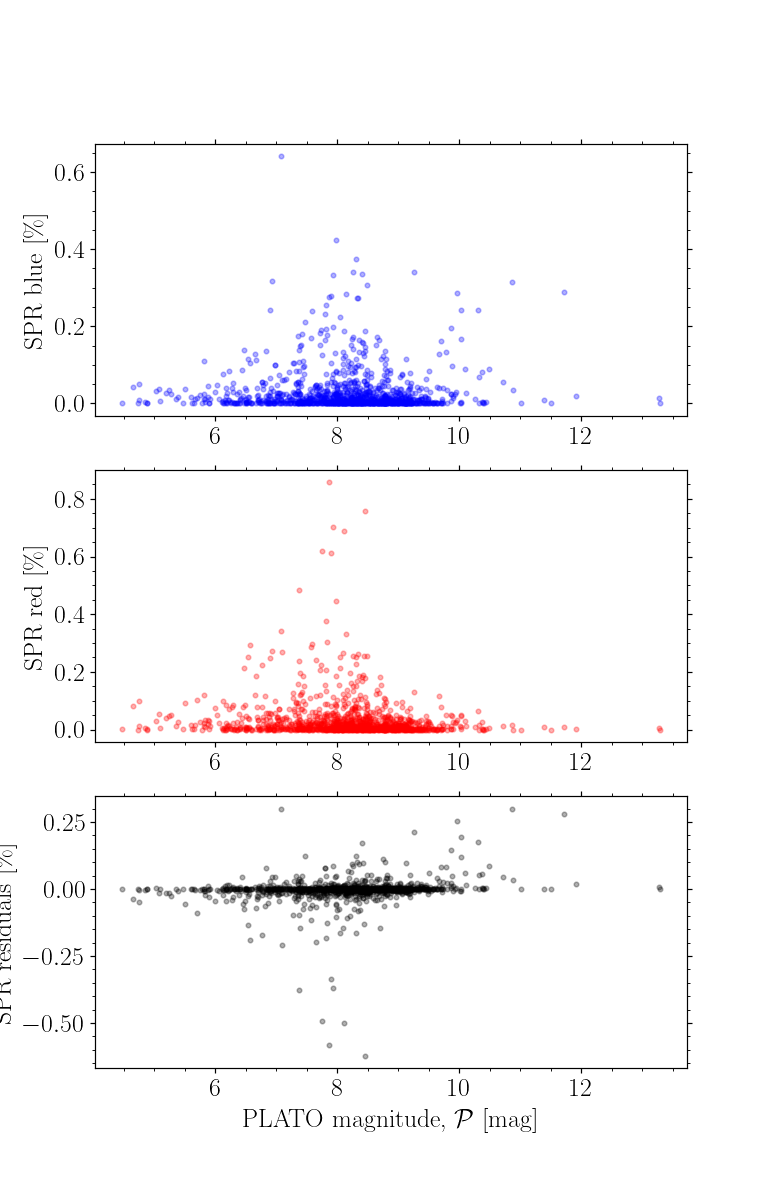

In [100]:
fig, ax = plt.subplots(3,1, figsize=(7,11))
# SPR of non-zero contamination
dx = dt0[dt0.SPR_b > 0]
dx.SPR_b *= 100
dx.SPR_r *= 100

# Plots
ax[0].plot(dx.PBmag, dx.SPR_b, 'b.', alpha=0.3)
# ax[0].set_yscale('log')
ax[1].plot(dx.PBmag, dx.SPR_r, 'r.', alpha=0.3)
# ax[1].set_yscale('log')
ax[2].plot(dx.PBmag, dx.SPR_b-dx.SPR_r, 'k.', alpha=0.3)
# ax[2].set_yscale('log')
# Labels
ax[0].set_ylabel('SPR blue [\%]')
ax[1].set_ylabel('SPR red [\%]')
ax[2].set_ylabel('SPR residuals [\%]')
ax[2].set_xlabel(r'PLATO magnitude, $\mathcal{P}$ [mag]')
# Save to file
fig.savefig(fdir/'SPR_vs_Pmag.png', bbox_inches='tight', dpi=200)

<IPython.core.display.Javascript object>


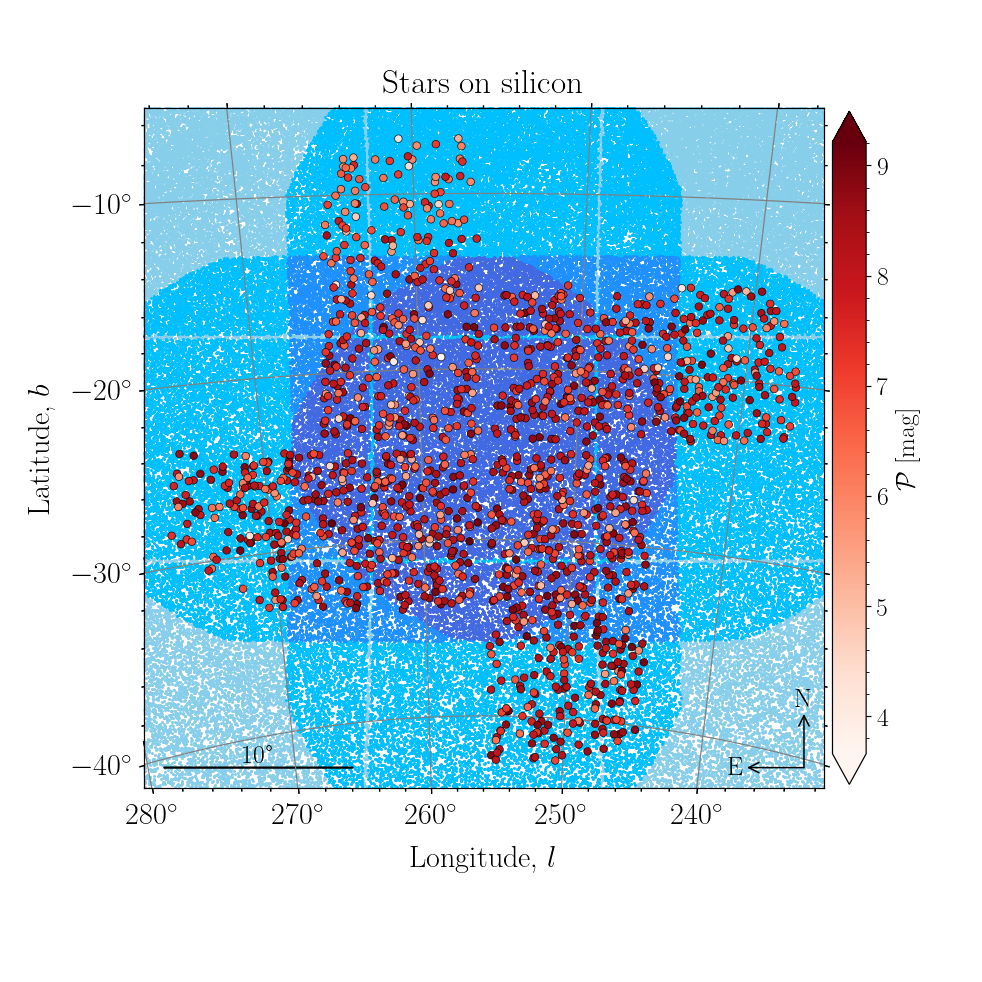

In [112]:
# Inspect the star not detected on silicon
dx = dt0[~dt0.SPR_b.isna()]
fig, ax = pt.plotPlatoFOV(
    'LOPS2', system='galactic', fovSize=20, ncamStars=True, cmap='Reds',
    raStars=dx.ra, decStars=dx.dec, c=dx.Pmag,
    clabel=r'$\mathcal{P}$ [mag]', s=100, lw=0.4,
    title='Stars on silicon', figsize=(9,9),
)
fig.savefig(fdir/'footprint_stars_on_silicon.png', bbox_inches='tight', dpi=200)

<IPython.core.display.Javascript object>


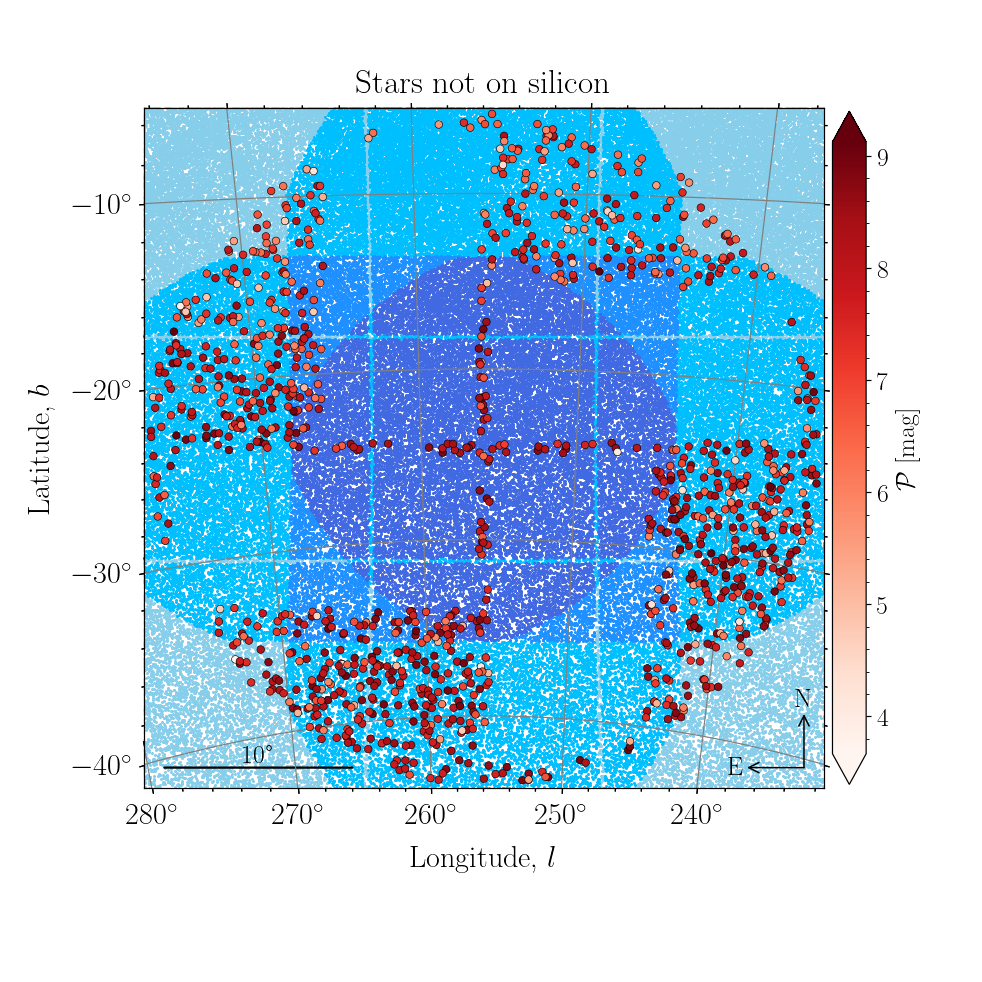

In [115]:
# Inspect the star not detected on silicon
dx = dt0[dt0.SPR_b.isna()]
fig, ax = pt.plotPlatoFOV(
    'LOPS2', system='galactic', fovSize=20, ncamStars=True, cmap='Reds',
    raStars=dx.ra, decStars=dx.dec, c=dx.Pmag,
    clabel=r'$\mathcal{P}$ [mag]', s=100, lw=0.4,
    title='Stars not on silicon', figsize=(9,9),
)
fig.savefig(fdir/'footprint_stars_not_on_silicon.png', bbox_inches='tight', dpi=200)